### 网络架构
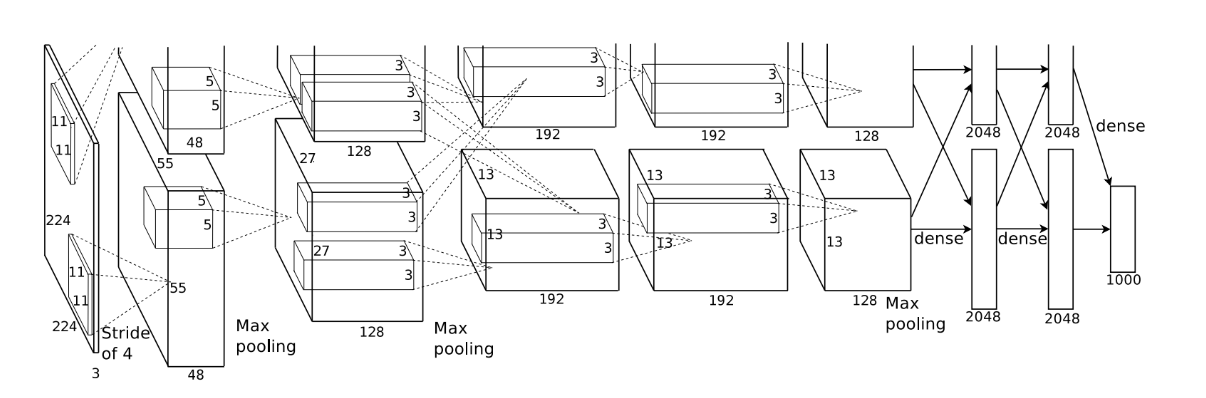

| 层次 | 类型 | 输出尺寸 | 说明 |
|---|---|---|---|
| 输入层 | - | 224×224×3 | RGB 图像输入 |
| 第1层 | 卷积层（11×11，stride=4）+ ReLU + LRN + MaxPool | 55×55×96 | 较大卷积核用于初始特征提取 |
| 第2层 | 卷积层（5×5，stride=1）+ ReLU + LRN + MaxPool | 27×27×256 | 局部响应归一化（LRN）提高泛化能力 |
| 第3层 | 卷积层（3×3）+ ReLU | 13×13×384 | 更细粒度的特征提取 |
| 第4层 | 卷积层（3×3）+ ReLU | 13×13×384 | 与第3层配合提取复杂模式 |
| 第5层 | 卷积层（3×3）+ ReLU + MaxPool | 6×6×256 | 下采样提取语义信息 |
| 第6层 | 全连接层 + ReLU + Dropout | 4096 | 用于分类的高级特征 |
| 第7层 | 全连接层 + ReLU + Dropout | 4096 | 防止过拟合 |
| 第8层 | 全连接层 + Softmax | 1000 | 输出 1000 类概率分布 |



In [ ]:
import torch
import torch.nn as nn


class AlexNet(nn.Module):
    def __init__(self, num_classes=1000):
        super().__init__()
        self.features = nn.Sequential(
            # 第一层
            nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(size=5, alpha=1e-4, beta=0.75, k=2.0),
            nn.MaxPool2d(kernel_size=3, stride=2),
            # 第二层
            nn.Conv2d(96, 256, kernel_size=5, stride=1, padding=2),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(size=5, alpha=1e-4, beta=0.75, k=2.0),
            nn.MaxPool2d(kernel_size=3, stride=2),
            # 第三层
            nn.Conv2d(256, 384, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            # 第四层
            nn.Conv2d(384, 384, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            # 第五层
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.classifier = nn.Sequential(
            # 第六层
            nn.Dropout(p=0.5),
            nn.Linear(6 * 6 * 256, 4096),
            nn.ReLU(inplace=True),
            # 第七层
            nn.Dropout(p=0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            # 第八层
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

### 测试模型构建

In [5]:
x = torch.randn((10, 3, 224, 224))
model = AlexNet(1000)
y = model(x)
print(y.shape)

torch.Size([10, 1000])
